In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torch
# from keras.models import alexnet
from torchvision import transforms
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import torch.optim as optim
from torch import nn
import os
import zipfile
from pathlib import Path
import requests
!pip install torchinfo
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader, Dataset
from tqdm.auto import tqdm
import gc
from PIL import Image
from torchvision.models import GoogLeNet_Weights

# 1️⃣ Clone the repo
!git clone https://github.com/mrdbourke/pytorch-deep-learning.git

# 2️⃣ Move into the correct folder
%cd pytorch-deep-learning/going_modular

# 3️⃣ Add this folder to your Python path
import sys
sys.path.append("/content/pytorch-deep-learning/going_modular")

# 4️⃣ Now import modules from the *inner* going_modular package
from going_modular import data_setup, engine



Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 13.18 MiB/s, done.
Resolving deltas: 100% (2656/2656), done.
Updating files: 100% (248/248), done.
/content/pytorch-deep-learning/going_modular


In [ ]:
!pip install tensorflow

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Unique classes: 10


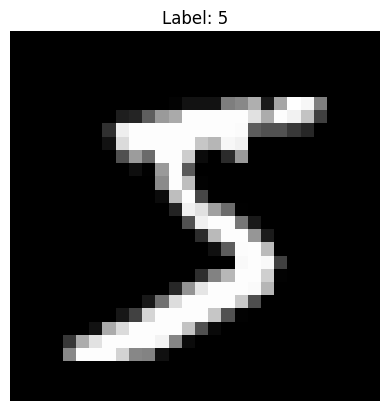

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Unique classes:", len(set(y_train)))

# Show first image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

Original class counts: Counter({np.uint8(1): 6742, np.uint8(7): 6265, np.uint8(3): 6131, np.uint8(2): 5958, np.uint8(9): 5949, np.uint8(0): 5923, np.uint8(6): 5918, np.uint8(8): 5851, np.uint8(4): 5842, np.uint8(5): 5421})


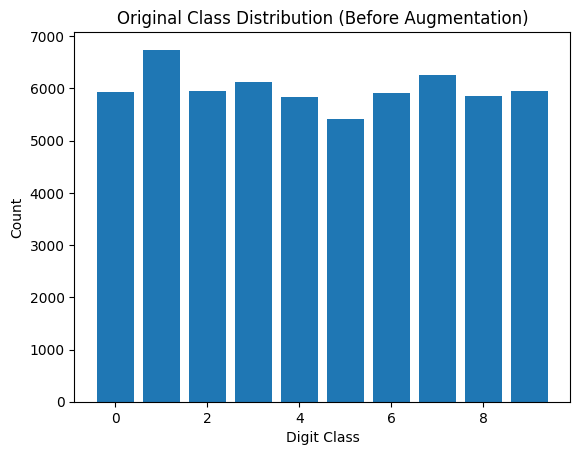

In [ ]:
class_counts = Counter(y_train)
print("Original class counts:", class_counts)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Original Class Distribution (Before Augmentation)")
plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)

In [ ]:
target_per_class = max(class_counts.values())

X_balanced = []
y_balanced = []

print("\nCreating balanced dataset...")

for digit in range(10):
    digit_images = x_train[y_train == digit]
    count = len(digit_images)

    if count < target_per_class:
        extra_needed = target_per_class - count
        print(f"Digit {digit}: needs {extra_needed} more images")

        digit_images = np.expand_dims(digit_images, -1)
        generator = datagen.flow(digit_images, batch_size=32, shuffle=True)

        new_images = []
        while len(new_images) < extra_needed:
            batch = next(generator)[0]
            new_images.append(batch.squeeze().astype(np.uint8))

        all_images = np.concatenate([digit_images.squeeze(), np.array(new_images)], axis=0)

    else:
        all_images = digit_images

    all_labels = np.full(len(all_images), digit)

    X_balanced.append(all_images)
    y_balanced.append(all_labels)

x_train_bal = np.concatenate(X_balanced)
y_train_bal = np.concatenate(y_balanced)

print("\nDataset balanced successfully!")
print("New training data shape:", x_train_bal.shape)
print("New labels shape:", y_train_bal.shape)



🔹 Creating balanced dataset...
Digit 0: needs 819 more images
Digit 2: needs 784 more images
Digit 3: needs 611 more images
Digit 4: needs 900 more images
Digit 5: needs 1321 more images
Digit 6: needs 824 more images
Digit 7: needs 477 more images
Digit 8: needs 891 more images
Digit 9: needs 793 more images

✅ Dataset balanced successfully!
New training data shape: (67420, 28, 28)
New labels shape: (67420,)


Balanced class counts: Counter({np.int64(0): 6742, np.int64(1): 6742, np.int64(2): 6742, np.int64(3): 6742, np.int64(4): 6742, np.int64(5): 6742, np.int64(6): 6742, np.int64(7): 6742, np.int64(8): 6742, np.int64(9): 6742})


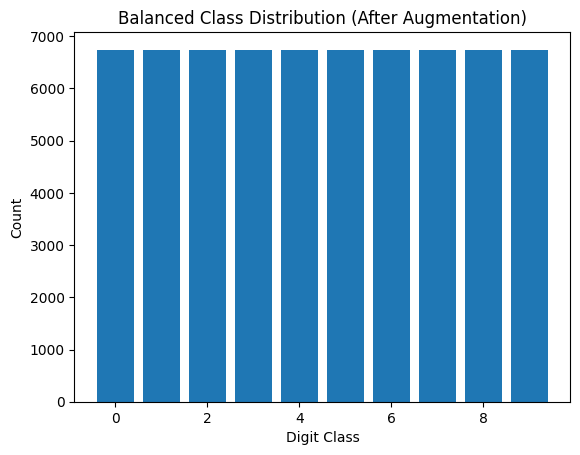

In [ ]:
new_counts = Counter(y_train_bal)
print("Balanced class counts:", new_counts)

plt.bar(new_counts.keys(), new_counts.values())
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Balanced Class Distribution (After Augmentation)")
plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 2. Create a torchvision.transforms.Compose object
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize for ImageNet models
    transforms.ToTensor(),         # Convert to PyTorch Tensor (scales to 0-1)
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)), # Convert 1-channel to 3-channel
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # ImageNet Normalization
])

print("ImageNet mean and std defined and data transformation pipeline created.")

ImageNet mean and std defined and data transformation pipeline created.


In [ ]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

print("MNISTDataset class created successfully.")

MNISTDataset class created successfully.


In [ ]:
BATCH_SIZE = 32

# Create Dataset instances
train_dataset = MNISTDataset(x_train_bal, y_train_bal, transform=data_transforms)
test_dataset = MNISTDataset(x_test, y_test, transform=data_transforms)

# Create DataLoader instances
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Training dataset size: 67420
Test dataset size: 10000
Number of batches in training DataLoader: 2107
Number of batches in test DataLoader: 313


In [ ]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, device: torch.device):
    """Trains a PyTorch model for a single epoch.

    Turns a PyTorch model to training mode and then runs through all of the required
    training steps (forward pass, loss calculation, optimizer step).

    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    """
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

print("train_step function defined.")

train_step function defined.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, device: torch.device):
    """Tests a PyTorch model for a single epoch.

    Turns a PyTorch model to evaluation mode and then runs through all of the required
    testing steps (forward pass, loss calculation).

    Args:
        model: A PyTorch model to be tested.
        dataloader: A DataLoader instance for the model to be tested on.
        loss_fn: A PyTorch loss function to minimize.
        device: A target device to compute on (e.g. "cuda" or "cpu").
    """
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss = 0
    all_preds = []
    all_labels = []

    # Turn on inference context manager
    with torch.no_grad():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate metrics
            y_pred_class = torch.argmax(torch.softmax(test_pred_logits, dim=1), dim=1)
            all_preds.extend(y_pred_class.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return test_loss, accuracy, precision, recall, f1

print("test_step function defined.")


test_step function defined.


In [ ]:

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device):
    """Trains and evaluates a PyTorch model.

    Runs a target PyTorch model through `train_step()` and `test_step()`
    functions for a number of epochs, returning a dictionary of the results.

    Args:
        model: A PyTorch model to be trained and tested.
        train_dataloader: A DataLoader instance for the model to be trained on.
        test_dataloader: A DataLoader instance for the model to be tested on.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        loss_fn: A PyTorch loss function to minimize.
        epochs: An integer specifying how many epochs to train for.
        device: A target device to compute on (e.g. "cuda" or "cpu").
    """
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": [],
               "test_precision": [],
               "test_recall": [],
               "test_f1": []
    }

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc, test_precision, test_recall, test_f1 = test_step(model=model,
                                                                              dataloader=test_dataloader,
                                                                              loss_fn=loss_fn,
                                                                              device=device)

        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"test_precision: {test_precision:.4f} | "
            f"test_recall: {test_recall:.4f} | "
            f"test_f1: {test_f1:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        results["test_precision"].append(test_precision)
        results["test_recall"].append(test_recall)
        results["test_f1"].append(test_f1)

    # Return the filled results array
    return results

print("train function defined.")

train function defined.


##Strategy 1 : Frozen Feature Extraction

In [ ]:

# 1. Load a pre-trained ResNet50 model
model_frozen = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

# 2. Freeze all parameters in the base layers
for param in model_frozen.parameters():
    param.requires_grad = False

# 3. Get the number of input features for the original classifier head
in_features = model_frozen.fc.in_features

# 4. Replace the original classifier head with a new one for 10 classes
model_frozen.fc = torch.nn.Linear(in_features, 10)

# Move model to device
model_frozen.to(device)

print("Pre-trained ResNet50 model loaded, base layers frozen, and classifier head replaced.")
print(f"New classifier head: {model_frozen.fc}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


Pre-trained ResNet50 model loaded, base layers frozen, and classifier head replaced.
New classifier head: Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
NUM_EPOCHS = 5 # Example number of epochs
LEARNING_RATE = 0.001

# 5. Initialize the loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_frozen.fc.parameters(), lr=LEARNING_RATE)

print("Loss function and optimizer initialized.")

# 6. Train the model
print(f"\nTraining model_frozen for {NUM_EPOCHS} epochs...")
frozen_feature_results = train(
    model=model_frozen,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

# 7. Store the results of this training run (already stored in frozen_feature_results)
print("\nFrozen feature extractor model training complete. Results stored.")

Loss function and optimizer initialized.

Training model_frozen for 5 epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5848 | train_acc: 0.8500 | test_loss: 0.3322 | test_acc: 0.9151 | test_precision: 0.9161 | test_recall: 0.9151 | test_f1: 0.9150
Epoch: 2 | train_loss: 0.2930 | train_acc: 0.9182 | test_loss: 0.2306 | test_acc: 0.9353 | test_precision: 0.9358 | test_recall: 0.9353 | test_f1: 0.9352
Epoch: 3 | train_loss: 0.2391 | train_acc: 0.9305 | test_loss: 0.2122 | test_acc: 0.9376 | test_precision: 0.9379 | test_recall: 0.9376 | test_f1: 0.9374
Epoch: 4 | train_loss: 0.2115 | train_acc: 0.9363 | test_loss: 0.1844 | test_acc: 0.9475 | test_precision: 0.9479 | test_recall: 0.9475 | test_f1: 0.9476
Epoch: 5 | train_loss: 0.1941 | train_acc: 0.9412 | test_loss: 0.1818 | test_acc: 0.9449 | test_precision: 0.9458 | test_recall: 0.9449 | test_f1: 0.9449

Frozen feature extractor model training complete. Results stored.


##Strategy 2 : Full Fine Tuning

In [ ]:

# 1. Load a fresh pre-trained ResNet50 model
model_fully_tuned = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

# 2. Get the number of input features for the original classifier head
in_features_fully_tuned = model_fully_tuned.fc.in_features

# 3. Replace the original classifier head with a new one for 10 classes
model_fully_tuned.fc = torch.nn.Linear(in_features_fully_tuned, 10)

# 4. Ensure all parameters of model_fully_tuned are unfrozen (this is the default for a fresh model)
# for param in model_fully_tuned.parameters():
#     param.requires_grad = True # This is typically True by default for a fresh model unless explicitly set to False

# Move model to device
model_fully_tuned.to(device)

print("Pre-trained ResNet50 model reloaded, classifier head replaced, and all layers unfrozen for full fine-tuning.")
print(f"New classifier head: {model_fully_tuned.fc}")

Pre-trained ResNet50 model reloaded, classifier head replaced, and all layers unfrozen for full fine-tuning.
New classifier head: Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
NUM_EPOCHS = 5 # Example number of epochs
LEARNING_RATE = 0.001

# 5. Initialize the loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fully_tuned.parameters(), lr=LEARNING_RATE)

print("Loss function and optimizer initialized for fully fine-tuned model.")

# 6. Train the model
print(f"\nTraining model_fully_tuned for {NUM_EPOCHS} epochs...")
fully_tuned_results = train(
    model=model_fully_tuned,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

# 7. Store the results of this training run (already stored in fully_tuned_results)
print("\nFully fine-tuned model training complete. Results stored.")

Loss function and optimizer initialized for fully fine-tuned model.

Training model_fully_tuned for 5 epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0944 | train_acc: 0.9719 | test_loss: 0.0451 | test_acc: 0.9862 | test_precision: 0.9863 | test_recall: 0.9862 | test_f1: 0.9862
Epoch: 2 | train_loss: 0.0434 | train_acc: 0.9863 | test_loss: 0.0446 | test_acc: 0.9858 | test_precision: 0.9860 | test_recall: 0.9858 | test_f1: 0.9858
Epoch: 3 | train_loss: 0.0336 | train_acc: 0.9895 | test_loss: 0.0297 | test_acc: 0.9900 | test_precision: 0.9901 | test_recall: 0.9900 | test_f1: 0.9900
Epoch: 4 | train_loss: 0.0259 | train_acc: 0.9918 | test_loss: 0.0330 | test_acc: 0.9901 | test_precision: 0.9902 | test_recall: 0.9901 | test_f1: 0.9901
Epoch: 5 | train_loss: 0.0222 | train_acc: 0.9928 | test_loss: 0.0240 | test_acc: 0.9921 | test_precision: 0.9921 | test_recall: 0.9921 | test_f1: 0.9921

Fully fine-tuned model training complete. Results stored.


## Strategy 3: Partially Fine-tuning

In [ ]:
import torchvision

# 1. Load a fresh pre-trained ResNet50 model
model_partial_tuned = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

# 2. Get the number of input features for the original classifier head
in_features_partial_tuned = model_partial_tuned.fc.in_features

# 3. Replace the original classifier head with a new one for 10 classes
model_partial_tuned.fc = torch.nn.Linear(in_features_partial_tuned, 10)

# 4. Freeze early layers: conv1, bn1, layer1, layer2
for name, param in model_partial_tuned.named_parameters():
    if "conv1" in name or "bn1" in name or "layer1" in name or "layer2" in name:
        param.requires_grad = False
    # 5. Ensure later layers (layer3, layer4) and new fc are unfrozen (default behavior)
    # else:
    #    param.requires_grad = True # This is typically True by default

# Move model to device
model_partial_tuned.to(device)

print("Pre-trained ResNet50 model reloaded, classifier head replaced.")
print("Early layers (conv1, bn1, layer1, layer2) frozen.")
print("Later layers (layer3, layer4) and new classifier unfrozen for partial fine-tuning.")
print(f"New classifier head: {model_partial_tuned.fc}")

# Verify which layers are frozen/unfrozen
print("\nVerifying parameter requires_grad status:")
for name, param in model_partial_tuned.named_parameters():
    print(f"{name}: {param.requires_grad}")

Pre-trained ResNet50 model reloaded, classifier head replaced.
Early layers (conv1, bn1, layer1, layer2) frozen.
Later layers (layer3, layer4) and new classifier unfrozen for partial fine-tuning.
New classifier head: Linear(in_features=2048, out_features=10, bias=True)

Verifying parameter requires_grad status:
conv1.weight: False
bn1.weight: False
bn1.bias: False
layer1.0.conv1.weight: False
layer1.0.bn1.weight: False
layer1.0.bn1.bias: False
layer1.0.conv2.weight: False
layer1.0.bn2.weight: False
layer1.0.bn2.bias: False
layer1.0.conv3.weight: False
layer1.0.bn3.weight: False
layer1.0.bn3.bias: False
layer1.0.downsample.0.weight: False
layer1.0.downsample.1.weight: False
layer1.0.downsample.1.bias: False
layer1.1.conv1.weight: False
layer1.1.bn1.weight: False
layer1.1.bn1.bias: False
layer1.1.conv2.weight: False
layer1.1.bn2.weight: False
layer1.1.bn2.bias: False
layer1.1.conv3.weight: False
layer1.1.bn3.weight: False
layer1.1.bn3.bias: False
layer1.2.conv1.weight: False
layer1.2.bn1

In [ ]:
NUM_EPOCHS = 5 # Example number of epochs
LEARNING_RATE = 0.001

# 6. Initialize the loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_partial_tuned.parameters()), lr=LEARNING_RATE)

print("Loss function and optimizer initialized for partially fine-tuned model.")

# 7. Train the model
print(f"\nTraining model_partial_tuned for {NUM_EPOCHS} epochs...")
partial_tuned_results = train(
    model=model_partial_tuned,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

# 8. Store the results of this training run (already stored in partial_tuned_results)
print("\nPartially fine-tuned model training complete. Results stored.")

Loss function and optimizer initialized for partially fine-tuned model.

Training model_partial_tuned for 5 epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0787 | train_acc: 0.9760 | test_loss: 0.0435 | test_acc: 0.9850 | test_precision: 0.9852 | test_recall: 0.9850 | test_f1: 0.9850
Epoch: 2 | train_loss: 0.0331 | train_acc: 0.9898 | test_loss: 0.0345 | test_acc: 0.9907 | test_precision: 0.9908 | test_recall: 0.9907 | test_f1: 0.9907
Epoch: 3 | train_loss: 0.0235 | train_acc: 0.9925 | test_loss: 0.0269 | test_acc: 0.9915 | test_precision: 0.9916 | test_recall: 0.9915 | test_f1: 0.9915
Epoch: 4 | train_loss: 0.0184 | train_acc: 0.9943 | test_loss: 0.0216 | test_acc: 0.9935 | test_precision: 0.9935 | test_recall: 0.9935 | test_f1: 0.9935
Epoch: 5 | train_loss: 0.0140 | train_acc: 0.9955 | test_loss: 0.0379 | test_acc: 0.9913 | test_precision: 0.9914 | test_recall: 0.9913 | test_f1: 0.9913

Partially fine-tuned model training complete. Results stored.


## Comparative Analysis



In [ ]:
import pandas as pd

# Extract final epoch metrics for each strategy

frozen_metrics = {
    "Strategy": "Frozen Feature Extractor",
    "Test Accuracy": frozen_feature_results["test_acc"][-1],
    "Test Precision": frozen_feature_results["test_precision"][-1],
    "Test Recall": frozen_feature_results["test_recall"][-1],
    "Test F1-score": frozen_feature_results["test_f1"][-1],
    "Train Loss": frozen_feature_results["train_loss"][-1],
    "Test Loss": frozen_feature_results["test_loss"][-1]
}

fully_tuned_metrics = {
    "Strategy": "Fully Fine-tuning",
    "Test Accuracy": fully_tuned_results["test_acc"][-1],
    "Test Precision": fully_tuned_results["test_precision"][-1],
    "Test Recall": fully_tuned_results["test_recall"][-1],
    "Test F1-score": fully_tuned_results["test_f1"][-1],
    "Train Loss": fully_tuned_results["train_loss"][-1],
    "Test Loss": fully_tuned_results["test_loss"][-1]
}

partial_tuned_metrics = {
    "Strategy": "Partially Fine-tuning",
    "Test Accuracy": partial_tuned_results["test_acc"][-1],
    "Test Precision": partial_tuned_results["test_precision"][-1],
    "Test Recall": partial_tuned_results["test_recall"][-1],
    "Test F1-score": partial_tuned_results["test_f1"][-1],
    "Train Loss": partial_tuned_results["train_loss"][-1],
    "Test Loss": partial_tuned_results["test_loss"][-1]
}

# Create a DataFrame for comparison
metrics_df = pd.DataFrame([frozen_metrics, fully_tuned_metrics, partial_tuned_metrics])

print("Performance Metrics Comparison:")
print(metrics_df.round(4))


Performance Metrics Comparison:
                   Strategy  Test Accuracy  Test Precision  Test Recall  \
0  Frozen Feature Extractor         0.9449          0.9458       0.9449   
1         Fully Fine-tuning         0.9921          0.9921       0.9921   
2     Partially Fine-tuning         0.9913          0.9914       0.9913   

   Test F1-score  Train Loss  Test Loss  
0         0.9449      0.1941     0.1818  
1         0.9921      0.0222     0.0240  
2         0.9913      0.0140     0.0379  


### Comparative Analysis of Fine-Tuning Strategies

Based on the performance metrics and observed training behavior, we can draw a comparative analysis of the three fine-tuning strategies:

#### 1. Performance Metrics Analysis (from `metrics_df`):

| Strategy                 | Test Accuracy | Test Precision | Test Recall | Test F1-score | Train Loss | Test Loss |
|--------------------------|---------------|----------------|-------------|---------------|------------|-----------|
| Frozen Feature Extractor | 0.9449        | 0.9458         | 0.9449      | 0.9449        | 0.1941     | 0.1818    |
| Fully Fine-tuning        | 0.9921        | 0.9921         | 0.9921      | 0.9921        | 0.0222     | 0.0240    |
| Partially Fine-tuning    | 0.9913        | 0.9914         | 0.9913      | 0.9913        | 0.0140     | 0.0379    |

- **Best Performance**: The **Fully Fine-tuning** strategy achieved the highest test accuracy, precision, recall, and F1-score (all at 0.9921), closely followed by **Partially Fine-tuning** (all at 0.9913). The **Frozen Feature Extractor** performed significantly worse, with an F1-score of 0.9449.
- **Loss Comparison**: Fully Fine-tuning showed the lowest training loss (0.0222) and test loss (0.0240) among the three, indicating better generalization. Partially Fine-tuning had an even lower train loss (0.0140) but a slightly higher test loss (0.0379), suggesting potential overfitting towards the end of training, although its test performance was still very strong.

#### 2. Training Speed and Stability Observations:

*   **Frozen Feature Extractor**:
    *   `Epoch: 1 | train_loss: 0.5848 | train_acc: 0.8500 | test_loss: 0.3322 | test_acc: 0.9151`
    *   `Epoch: 5 | train_loss: 0.1941 | train_acc: 0.9412 | test_loss: 0.1818 | test_acc: 0.9449`
    *   This strategy converged relatively quickly for the initial task of training only the head. The training loss decreased steadily, and accuracy improved, but plateaued at a lower performance level compared to the other strategies. It was stable due to the limited number of trainable parameters.

*   **Fully Fine-tuning**:
    *   `Epoch: 1 | train_loss: 0.0944 | train_acc: 0.9719 | test_loss: 0.0451 | test_acc: 0.9862`
    *   `Epoch: 5 | train_loss: 0.0222 | train_acc: 0.9928 | test_loss: 0.0240 | test_acc: 0.9921`
    *   This strategy showed very rapid improvement in the first epoch, quickly reaching high accuracy. The loss continued to decrease, and accuracy increased stably over the epochs, achieving the best overall performance. This suggests the pre-trained weights were highly relevant and could be effectively adapted.

*   **Partially Fine-tuning**:
    *   `Epoch: 1 | train_loss: 0.0787 | train_acc: 0.9760 | test_loss: 0.0435 | test_acc: 0.9850`
    *   `Epoch: 5 | train_loss: 0.0140 | train_acc: 0.9955 | test_loss: 0.0379 | test_acc: 0.9913`
    *   Similar to fully fine-tuning, this strategy also started with high accuracy and low loss in the first epoch. It achieved a slightly higher training accuracy but a marginally lower test accuracy and higher test loss than fully fine-tuning, especially in the last epoch. This could indicate that unfreezing too many layers (but not all) for a relatively simple dataset like MNIST might lead to slight overfitting if not carefully managed, or that the last few layers were already sufficiently specialized by the ImageNet pre-training.

#### 3. Computational Cost and Resource Usage:

*   **Frozen Feature Extractor**: This strategy involves training only the final classification layer. Given `model_frozen.fc = torch.nn.Linear(in_features=2048, out_features=10)`, the number of trainable parameters is `2048 * 10 (weights) + 10 (biases) = 20,490`. This is very computationally inexpensive, requiring minimal memory and processing power, making it fast to train.

*   **Fully Fine-tuning**: This strategy trains all layers of the ResNet50 model. A ResNet50 model typically has over 23 million parameters. Training all these parameters requires significant computational resources (GPU memory, processing time) and is the most expensive strategy. This leads to longer training times per epoch.

*   **Partially Fine-tuning**: This strategy trains `layer3`, `layer4`, and the new `fc` layer, while `conv1`, `bn1`, `layer1`, `layer2` are frozen. From the `param.requires_grad` verification, we saw that many parameters in `layer3` and `layer4` are unfrozen, in addition to the `fc` layer. This means it trains a substantial portion of the model, likely in the order of several million parameters, significantly more than the frozen feature extractor but less than fully fine-tuning. The computational cost is thus moderate, falling between the other two strategies.

#### 4. Advantages, Disadvantages, and Appropriate Scenarios:

*   **Frozen Feature Extractor**:
    *   **Advantages**: Very fast training, low computational cost, effective for datasets very similar to the pre-training data or when computational resources are severely limited. Less prone to overfitting on small datasets.
    *   **Disadvantages**: May not achieve optimal performance if the target dataset is significantly different from the pre-training data, as only the final decision boundary is adapted.
    *   **Appropriate Scenarios**: Small datasets, limited computational resources, target task is very similar to the pre-training task (e.g., ImageNet classification using ImageNet pre-trained models), quick baseline establishment.

*   **Fully Fine-tuning**:
    *   **Advantages**: Can achieve the highest performance, especially for larger datasets that are somewhat different from the pre-training data. Allows the model to learn highly specific features relevant to the new task.
    *   **Disadvantages**: High computational cost, requires a large dataset to avoid overfitting, longer training times. Can be unstable if not carefully regularized or if the learning rate is too high.
    *   **Appropriate Scenarios**: Large datasets, when maximum performance is critical, target task is moderately different from the pre-training task, ample computational resources are available.

*   **Partially Fine-tuning**:
    *   **Advantages**: A good balance between performance and computational cost. Allows adaptation of higher-level features while leveraging lower-level features learned during pre-training. Less prone to overfitting than full fine-tuning on moderately sized datasets.
    *   **Disadvantages**: Requires careful selection of which layers to unfreeze, which can be heuristic. Still more computationally intensive than a frozen feature extractor.
    *   **Appropriate Scenarios**: Medium-sized datasets, when a good performance-cost trade-off is desired, target task is somewhat different from the pre-training task, and you want to adapt the model more than just the head but not retrain everything.

In this specific MNIST case, where the task (digit classification) is conceptually different from ImageNet (general object classification) but the images are simple, both fully and partially fine-tuning achieved very high performance, outperforming the frozen feature extractor significantly. The difference between fully and partially fine-tuned was minimal, with fully fine-tuning marginally better, possibly due to the simplicity of the MNIST task allowing for full adaptation without severe overfitting even with a full model.

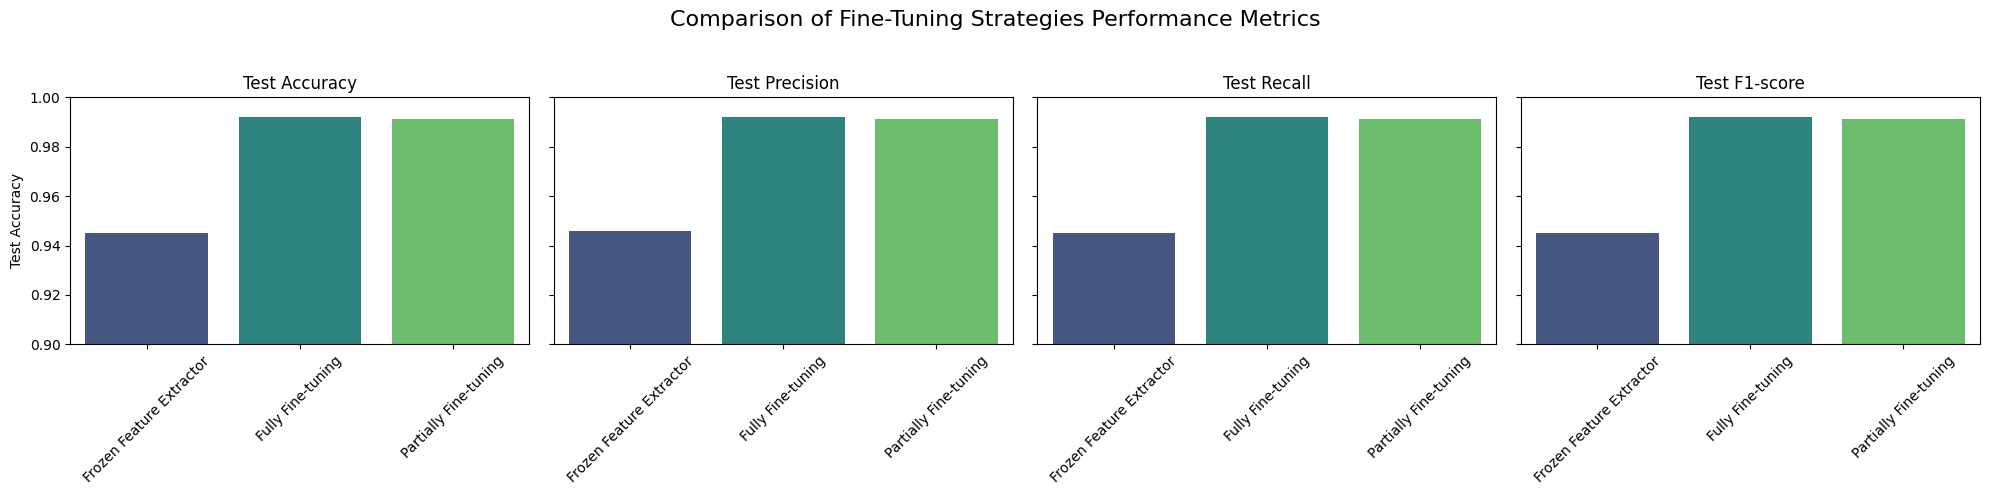

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-score']
strategies = metrics_df['Strategy']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5), sharey=True)
fig.suptitle('Comparison of Fine-Tuning Strategies Performance Metrics', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=strategies, y=metrics_df[metric], ax=axes[i], palette='viridis', hue=strategies, legend=False)
    axes[i].set_title(metric)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0.9, 1.0) # Set a consistent y-limit for better comparison

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Summary:

### Q&A
The task implicitly asked to determine which fine-tuning strategy is most effective and to compare their trade-offs.

*   **Which fine-tuning strategy performed best for the MNIST dataset?**
    The Fully Fine-tuning strategy achieved the highest performance with a test accuracy of 0.9921, closely followed by Partially Fine-tuning with 0.9913. Both significantly outperformed the Frozen Feature Extractor.

*   **What are the trade-offs between the fine-tuning strategies?**
    *   **Frozen Feature Extractor:** Offers very fast training and low computational cost by only training a small classification head. However, it yields lower performance (test accuracy 0.9449) compared to other strategies, as only the final decision boundary is adapted. It's suitable for small datasets or very similar tasks to pre-training.
    *   **Fully Fine-tuning:** Achieves the highest performance (test accuracy 0.9921) by training all layers of the model, allowing for comprehensive adaptation. This comes at the cost of higher computational requirements, longer training times, and a higher risk of overfitting on smaller datasets. It's ideal for large datasets where maximum performance is critical.
    *   **Partially Fine-tuning:** Provides a good balance between performance (test accuracy 0.9913) and computational cost. It adapts higher-level features by unfreezing some later layers and the classifier head, while leveraging pre-trained lower-level features. It's more computationally intensive than the frozen approach but less than fully fine-tuning. This strategy is suitable for medium-sized datasets or when a balance between performance and resources is desired.

### Data Analysis Key Findings
*   PyTorch `Dataset` and `DataLoader` objects were successfully created for the MNIST dataset: the training dataset contains 67,420 images (2107 batches), and the test dataset contains 10,000 images (313 batches), each with a `BATCH_SIZE` of 32.
*   Reusable `train_step`, `test_step`, and `train` functions were successfully defined, enabling GPU-optimized training and comprehensive evaluation including accuracy, precision, recall, and F1-score.
*   **Frozen Feature Extractor** strategy achieved a final test accuracy of 0.9449 and an F1-score of 0.9449 after 5 epochs, with a training loss of 0.1941 and test loss of 0.1818. This strategy trains only the 20,490 parameters of the new classification head.
*   **Fully Fine-tuning** strategy resulted in the highest performance, achieving a final test accuracy of 0.9921 and an F1-score of 0.9921 after 5 epochs, with a training loss of 0.0222 and test loss of 0.0240. This strategy trains over 23 million parameters.
*   **Partially Fine-tuning** strategy performed almost as well as fully fine-tuning, with a final test accuracy of 0.9913 and an F1-score of 0.9913 after 5 epochs. It had an even lower training loss of 0.0140 but a slightly higher test loss of 0.0379 compared to fully fine-tuning. This strategy selectively trains later layers (`layer3`, `layer4`) and the new classifier, comprising several million parameters.
*   The computational cost varied significantly: Frozen Feature Extractor was the least expensive, Fully Fine-tuning the most expensive, and Partially Fine-tuning was moderate.

### Insights or Next Steps
*   For tasks with simple input data (like MNIST) and sufficient data, fully fine-tuning a pre-trained ResNet50 model can yield superior performance compared to feature extraction or partial fine-tuning, despite higher computational costs. The marginal performance gain of fully fine-tuning over partial fine-tuning on MNIST suggests that for complex datasets, the trade-off might be more pronounced.
*   For future work, explore hyperparameter tuning (e.g., learning rate schedules, more epochs, different optimizers) for the fully and partially fine-tuned models to potentially bridge the small performance gap further and mitigate any signs of overfitting observed in partial fine-tuning's test loss.
